In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [3]:
dataset_path = Path().cwd().parent / "dataset"

# load dataset
train_df = pd.read_csv(dataset_path / "train.csv")

In [4]:
train_df.head(10)

,id,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,num_private,...,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group,status_group
0,69572,6000.0,2011-03-14,Roman,1390,Roman,34.938093,-9.856322,none,0,...,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe,functional
1,8776,0.0,2013-03-06,Grumeti,1399,GRUMETI,34.698766,-2.147466,Zahanati,0,...,soft,good,insufficient,insufficient,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional
2,34310,25.0,2013-02-25,Lottery Club,686,World vision,37.460664,-3.821329,Kwa Mahundi,0,...,soft,good,enough,enough,dam,dam,surface,communal standpipe multiple,communal standpipe,functional
3,67743,0.0,2013-01-28,Unicef,263,UNICEF,38.486161,-11.155298,Zahanati Ya Nanyumbu,0,...,soft,good,dry,dry,machine dbh,borehole,groundwater,communal standpipe multiple,communal standpipe,non functional
4,19728,0.0,2011-07-13,Action In A,0,Artisan,31.130847,-1.825359,Shuleni,0,...,soft,good,seasonal,seasonal,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional
5,9944,20.0,2011-03-13,Mkinga Distric Coun,0,DWE,39.172796,-4.765587,Tajiri,0,...,salty,salty,enough,enough,other,other,unknown,communal standpipe multiple,communal standpipe,functional
6,19816,0.0,2012-10-01,Dwsp,0,DWSP,33.362410,-3.766365,Kwa Ngomho,0,...,soft,good,enough,enough,machine dbh,borehole,groundwater,hand pump,hand pump,non functional
7,54551,0.0,2012-10-09,Rwssp,0,DWE,32.620617,-4.226198,Tushirikiane,0,...,milky,milky,enough,enough,shallow well,shallow well,groundwater,hand pump,hand pump,non functional
8,53934,0.0,2012-11-03,Wateraid,0,Water Aid,32.711100,-5.146712,Kwa Ramadhan Musa,0,...,salty,salty,seasonal,seasonal,machine dbh,borehole,groundwater,hand pump,hand pump,non functional
9,46144,0.0,2011-08-03,Isingiro Ho,0,Artisan,30.626991,-1.257051,Kwapeto,0,...,soft,good,enough,enough,shallow well,shallow well,groundwater,hand pump,hand pump,functional


In [5]:
# lets look at the more information about the dataset
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 59400 entries, 0 to 59399
Data columns (total 41 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     59400 non-null  int64  
 1   amount_tsh             59400 non-null  float64
 2   date_recorded          59400 non-null  str    
 3   funder                 55763 non-null  str    
 4   gps_height             59400 non-null  int64  
 5   installer              55745 non-null  str    
 6   longitude              59400 non-null  float64
 7   latitude               59400 non-null  float64
 8   wpt_name               59398 non-null  str    
 9   num_private            59400 non-null  int64  
 10  basin                  59400 non-null  str    
 11  subvillage             59029 non-null  str    
 12  region                 59400 non-null  str    
 13  region_code            59400 non-null  int64  
 14  district_code          59400 non-null  int64  
 15  lga          

In [6]:
# lets see the statistics of the dataset
train_df.describe()

,id,amount_tsh,gps_height,longitude,latitude,num_private,region_code,district_code,population,construction_year
count,59400.000000,59400.000000,59400.000000,59400.000000,5.940000e+04,59400.000000,59400.000000,59400.000000,59400.000000,59400.000000
mean,37115.131768,317.650385,668.297239,34.077427,-5.706033e+00,0.474141,15.297003,5.629747,179.909983,1300.652475
std,21453.128371,2997.574558,693.116350,6.567432,2.946019e+00,12.236230,17.587406,9.633649,471.482176,951.620547
min,0.000000,0.000000,-90.000000,0.000000,-1.164944e+01,0.000000,1.000000,0.000000,0.000000,0.000000
25%,18519.750000,0.000000,0.000000,33.090347,-8.540621e+00,0.000000,5.000000,2.000000,0.000000,0.000000
50%,37061.500000,0.000000,369.000000,34.908743,-5.021597e+00,0.000000,12.000000,3.000000,25.000000,1986.000000
75%,55656.500000,20.000000,1319.250000,37.178387,-3.326156e+00,0.000000,17.000000,5.000000,215.000000,2004.000000
max,74247.000000,350000.000000,2770.000000,40.345193,-2.000000e-08,1776.000000,99.000000,80.000000,30500.000000,2013.000000


In [7]:
train_df.shape

(59400, 41)

In [8]:
train_df.columns

Index(['id', 'amount_tsh', 'date_recorded', 'funder', 'gps_height',
       'installer', 'longitude', 'latitude', 'wpt_name', 'num_private',
       'basin', 'subvillage', 'region', 'region_code', 'district_code', 'lga',
       'ward', 'population', 'public_meeting', 'recorded_by',
       'scheme_management', 'scheme_name', 'permit', 'construction_year',
       'extraction_type', 'extraction_type_group', 'extraction_type_class',
       'management', 'management_group', 'payment', 'payment_type',
       'water_quality', 'quality_group', 'quantity', 'quantity_group',
       'source', 'source_type', 'source_class', 'waterpoint_type',
       'waterpoint_type_group', 'status_group'],
      dtype='str')

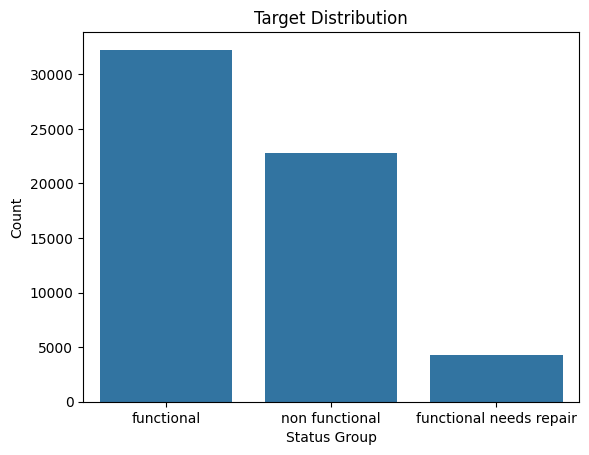

In [9]:
# lets see the target distribution
sns.countplot(x="status_group", data=train_df)
plt.title("Target Distribution")
plt.xlabel("Status Group")
plt.ylabel("Count")
plt.show()

In [10]:
# lets see the target distribution in percentage 
train_df["status_group"].value_counts(normalize=True) * 100

status_group
functional                 54.308081
non functional             38.424242
functional needs repair     7.267677
Name: proportion, dtype: float64

In [ ]:
# as we can see the target is imbalanced, we will need to handle this in the future steps
# we will use class balancing technique to handle the imbalanced target

In [12]:
# lets look at the distribution of the numerical features
num_features = train_df.select_dtypes(include = 'number').columns.tolist()
cat_features = train_df.select_dtypes(include = ['str', 'object']).columns.tolist()
label = train_df.status_group

In [13]:
print(f'There are {len(num_features)} numerical features')
print(f"And {len(cat_features)} categorical features")

There are 10 numerical features
And 31 categorical features


In [14]:
# lets look at the interactions between numerical features

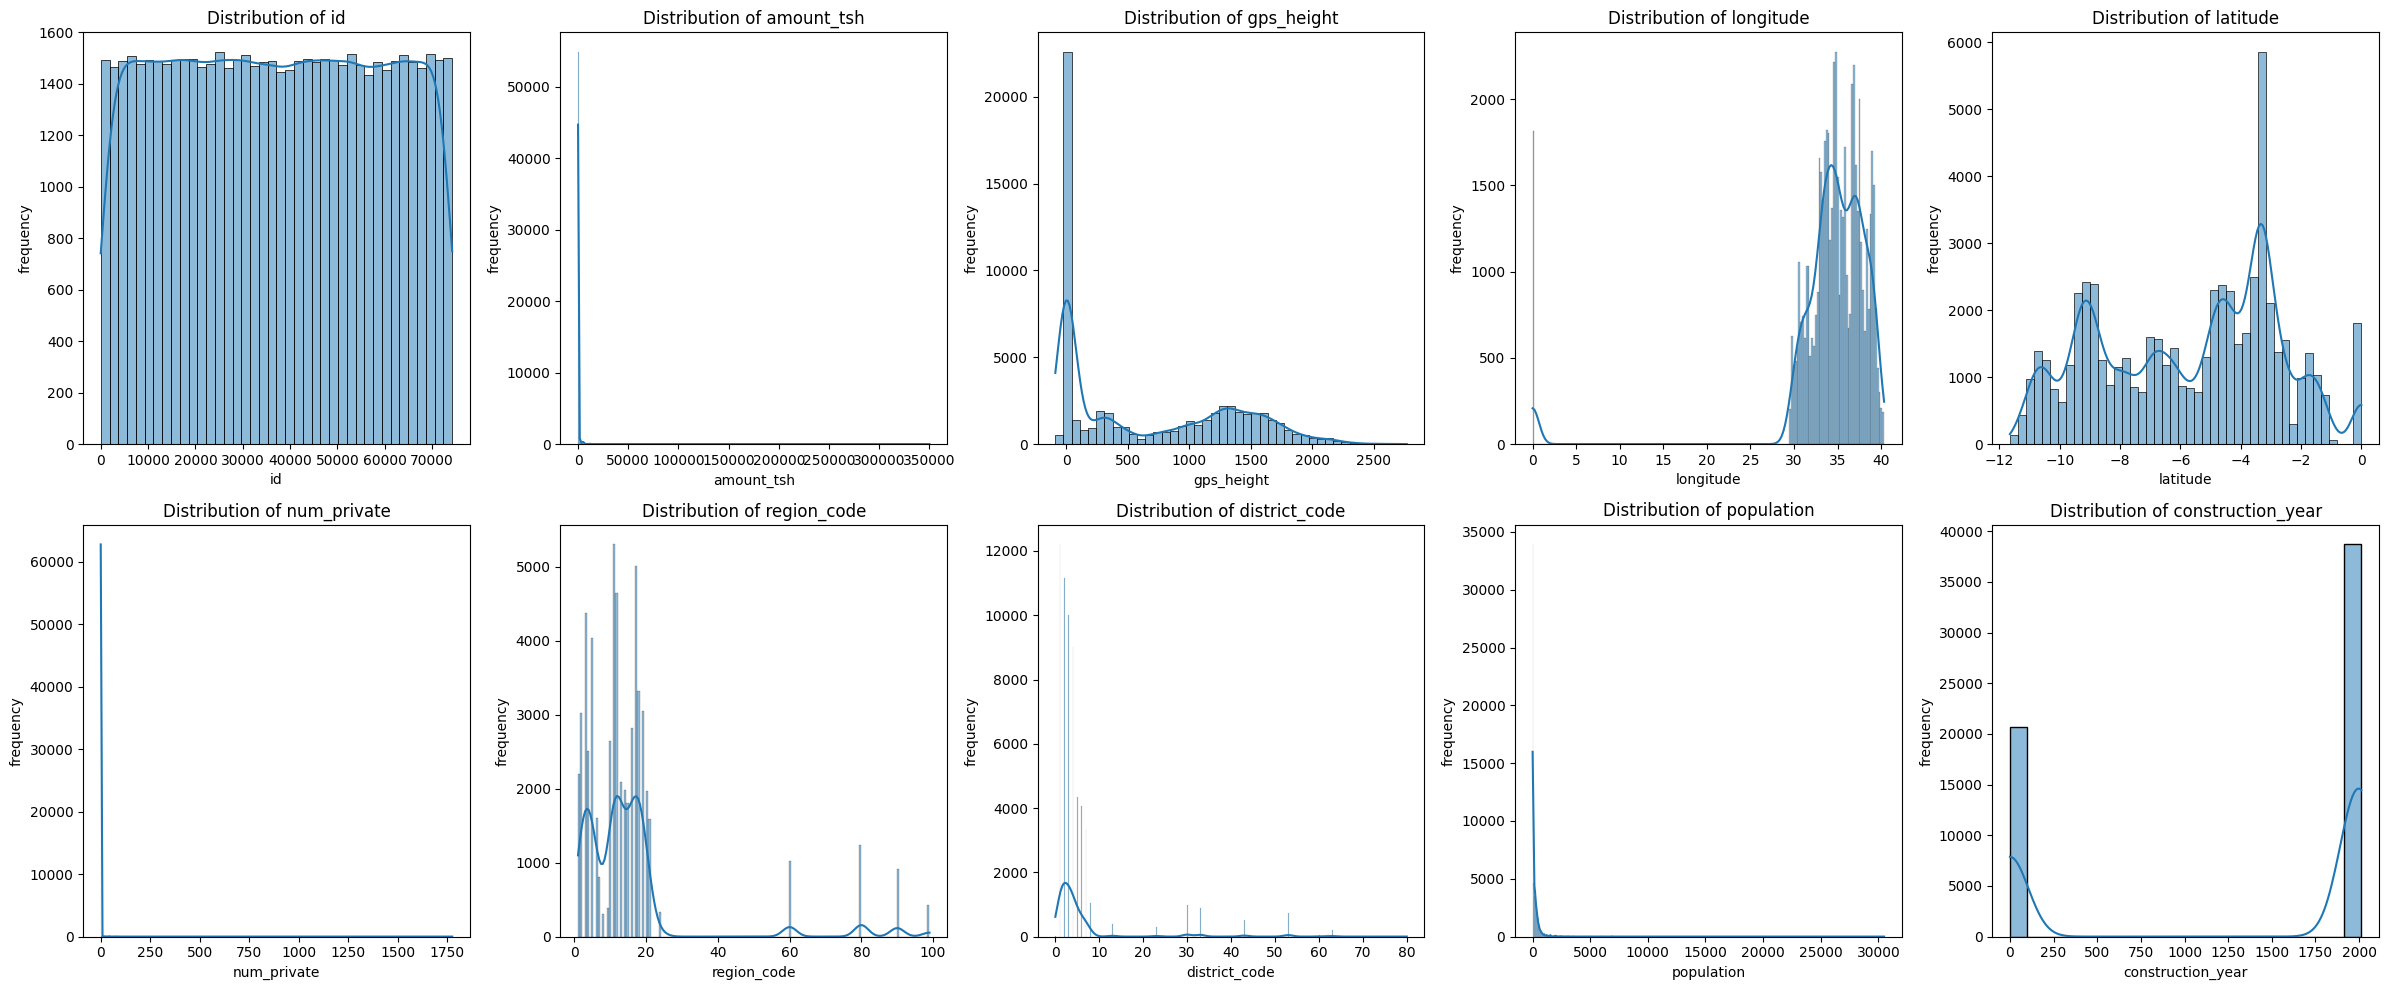

In [15]:
plt.figure(figsize=(24, 10))

for i, feature in enumerate(num_features, 1):
    plt.subplot(2, 5, i)
    sns.histplot(train_df[feature], kde = True) # type: ignore
    plt.title(f"Distribution of {feature}")
    plt.ylabel("frequency")

plt.tight_layout()
plt.show()


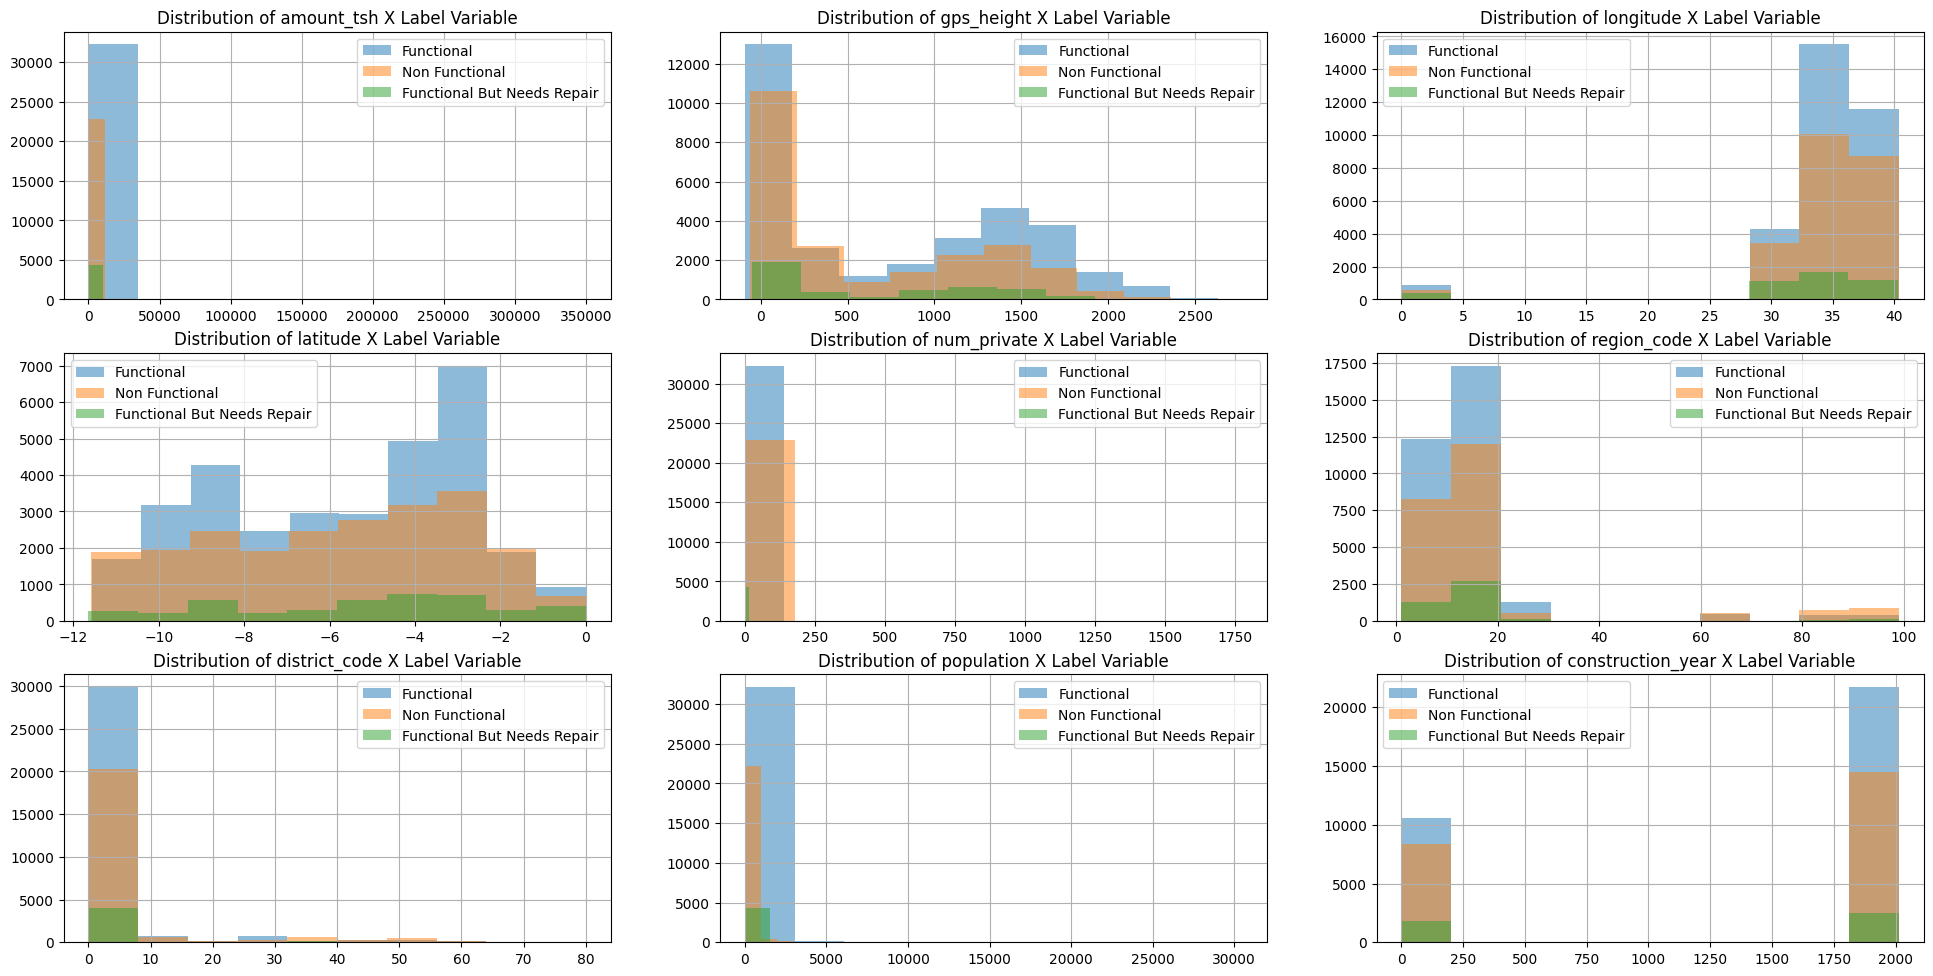

In [25]:
# lets look at the histogram of the numerical features along with the target variable
plt.figure(figsize=(24, 16))

for i, feature in enumerate(num_features):   
    if feature != 'id':
        plt.subplot(4, 3, i)
        train_df[label == 'functional'][feature].hist(grid = True, label = 'Functional', alpha = 0.5)
        train_df[label == 'non functional'][feature].hist(grid = True, label = 'Non Functional', alpha = 0.5)
        train_df[label == 'functional needs repair'][feature].hist(grid = True, label = 'Functional But Needs Repair', alpha = 0.5)
        plt.title(f'Distribution of {feature} X Label Variable')
        plt.legend()

plt.show()

In [ ]:
# from this we can notice multiple things
# firstly for the feature num_private that nearly all values are between 0 and around 200
# and that they are mostly non-functional, with some of them being functional and a really negligible number of 
# functional needs repair

# in the feature amount_ish when the amount is between 0 and 10k 
# we can see that the majoriy of the pumps are non functional, with some of them being functional needs repair
# and a really negligible number of functional needs repair
# however when the amount is over 10k we can see that literally all of them are functional
# which kinda makes it a really good feature to predict the target variable
# since being over 10k is a really strong indicator that the pump is functional

# thirdly the gps_height feature seems to be evenly distributed between 0 and 2500, 
# with the classes being evenly distributed across the different values of feature
# this makes it a not really good indicator of anything since it is not decisive in any way
# which can make it a weak feature 

# same goes for the lattitude and longitude features, they are evenly distributed across the different classes,
# which makes them not really good indicators of anything, and can make them weak features

# district_code and construction_year features have the same problem

# and finally the feature population seems to be a really good indicator 
# since populations between around 1000 - 5000 are mostly functional
# kinda indicates that the higher the population the more likely the pump is to be functional
# which makes sense since the more populated an area is the more likely for people to care about services and water pumps

In [ ]:
# lets look at the interactions between categorical features
# we will do so using a countplot for each categorical feature against the target variable
# since they are mostly categorical features we will have a lot of countplots to look at
# ill filter out the most important features first by looking at the unique values of each feature

In [29]:
for feature in cat_features:
    print(f"Number of Unique Values for {feature} feature: {train_df[feature].nunique()}")

Number of Unique Values for date_recorded feature: 356
Number of Unique Values for funder feature: 1896
Number of Unique Values for installer feature: 2145
Number of Unique Values for wpt_name feature: 37399
Number of Unique Values for basin feature: 9
Number of Unique Values for subvillage feature: 19287
Number of Unique Values for region feature: 21
Number of Unique Values for lga feature: 125
Number of Unique Values for ward feature: 2092
Number of Unique Values for public_meeting feature: 2
Number of Unique Values for recorded_by feature: 1
Number of Unique Values for scheme_management feature: 11
Number of Unique Values for scheme_name feature: 2695
Number of Unique Values for permit feature: 2
Number of Unique Values for extraction_type feature: 18
Number of Unique Values for extraction_type_group feature: 13
Number of Unique Values for extraction_type_class feature: 7
Number of Unique Values for management feature: 12
Number of Unique Values for management_group feature: 5
Numbe

In [ ]:
# so firstly 
# the wpt_name feature wont be used since it is just a name of the water point and it has no meaning
# the subvillage feature has lots of unique values around 20k
# which is really a lot as to whether we can use it or not will depend on the distribution
# of these values if they are evenly distributed then maybe it can be an indicator
# however it is most likely not the case because 20k is a lot on a dataset of 59k rows
# so we will most likely just drop it

# the scheme name has around 2700 unique values
# again is most likely to be not really useful 
# but we will look at its distribution across the values first 
# since who operates the water point can be an indicator of its functionality

# we will also drop the date recorded feature since it is has no meaning and we are not trying to build a time series model


# CONCLUSION:
# drop wpt_name, date_recorded
# check the distribution of subvillage, scheme_name, installer, funder, lga, ward before dropping them

In [37]:
for feature in ['subvillage', 'scheme_name', 'installer', 'funder', 'lga']:
    print(f"Value Counts for {feature}:")
    print(train_df[feature].value_counts(normalize=True))

Value Counts for subvillage:
subvillage
Madukani        0.008606
Shuleni         0.008572
Majengo         0.008504
Kati            0.006319
Mtakuja         0.004438
                  ...   
Hu              0.000017
Nduza           0.000017
Itete B         0.000017
Maore Kati      0.000017
Kikatanyemba    0.000017
Name: proportion, Length: 19287, dtype: float64
Value Counts for scheme_name:
scheme_name
K                       0.022295
Borehole                0.017849
Chalinze wate           0.013240
M                       0.013076
DANIDA                  0.012390
                          ...   
Upper RUVU              0.000033
TWESA                   0.000033
BL Nsherehehe           0.000033
Magati  gravity spri    0.000033
Mtawanya                0.000033
Name: proportion, Length: 2695, dtype: float64
Value Counts for installer:
installer
DWE                    0.312171
Government             0.032738
RWE                    0.021634
Commu                  0.019015
DANIDA             

In [ ]:
# well as we can see all these features are just better worth dropping than keeping them and handling their hastle
# even for smth like installer and funder since literally around 30% of them are from DWE
# while the rest are distributed with tiny proportions around the rest of labels
# even for smth like funder most of them are being funded from the government of tanzania

# conclusion: just drop them and do analysis on the rest

In [43]:
remove_list = ['subvillage', 'scheme_name', 'installer', 'funder', 'wpt_name', 'date_recorded', 'lga', 'ward']
cat_features = [feature for feature in cat_features if feature not in remove_list]

cat_features

['basin',
 'region',
 'public_meeting',
 'recorded_by',
 'scheme_management',
 'permit',
 'extraction_type',
 'extraction_type_group',
 'extraction_type_class',
 'management',
 'management_group',
 'payment',
 'payment_type',
 'water_quality',
 'quality_group',
 'quantity',
 'quantity_group',
 'source',
 'source_type',
 'source_class',
 'waterpoint_type',
 'waterpoint_type_group']

In [44]:
cat_features.remove('status_group') # because this is the target variable

for feature in cat_features:
    print(f"N Unique Values for {feature}: {train_df[feature].nunique()}")

N Unique Values for basin: 9
N Unique Values for region: 21
N Unique Values for public_meeting: 2
N Unique Values for recorded_by: 1
N Unique Values for scheme_management: 11
N Unique Values for permit: 2
N Unique Values for extraction_type: 18
N Unique Values for extraction_type_group: 13
N Unique Values for extraction_type_class: 7
N Unique Values for management: 12
N Unique Values for management_group: 5
N Unique Values for payment: 7
N Unique Values for payment_type: 7
N Unique Values for water_quality: 8
N Unique Values for quality_group: 6
N Unique Values for quantity: 5
N Unique Values for quantity_group: 5
N Unique Values for source: 10
N Unique Values for source_type: 7
N Unique Values for source_class: 3
N Unique Values for waterpoint_type: 7
N Unique Values for waterpoint_type_group: 6


In [45]:
print(f"Number of Categorical Features after dropping: {len(cat_features)}")

Number of Categorical Features after dropping: 22


In [ ]:
# now that we dropped them to 22 
# we can start looking at the interactions between these features
# ill go with the ones that have number of unique values less than 10

In [46]:
features_to_plot = [feature for feature in cat_features if train_df[feature].nunique() < 10]
features_to_plot

['basin',
 'public_meeting',
 'recorded_by',
 'permit',
 'extraction_type_class',
 'management_group',
 'payment',
 'payment_type',
 'water_quality',
 'quality_group',
 'quantity',
 'quantity_group',
 'source_type',
 'source_class',
 'waterpoint_type',
 'waterpoint_type_group']

In [47]:
len(features_to_plot)

16

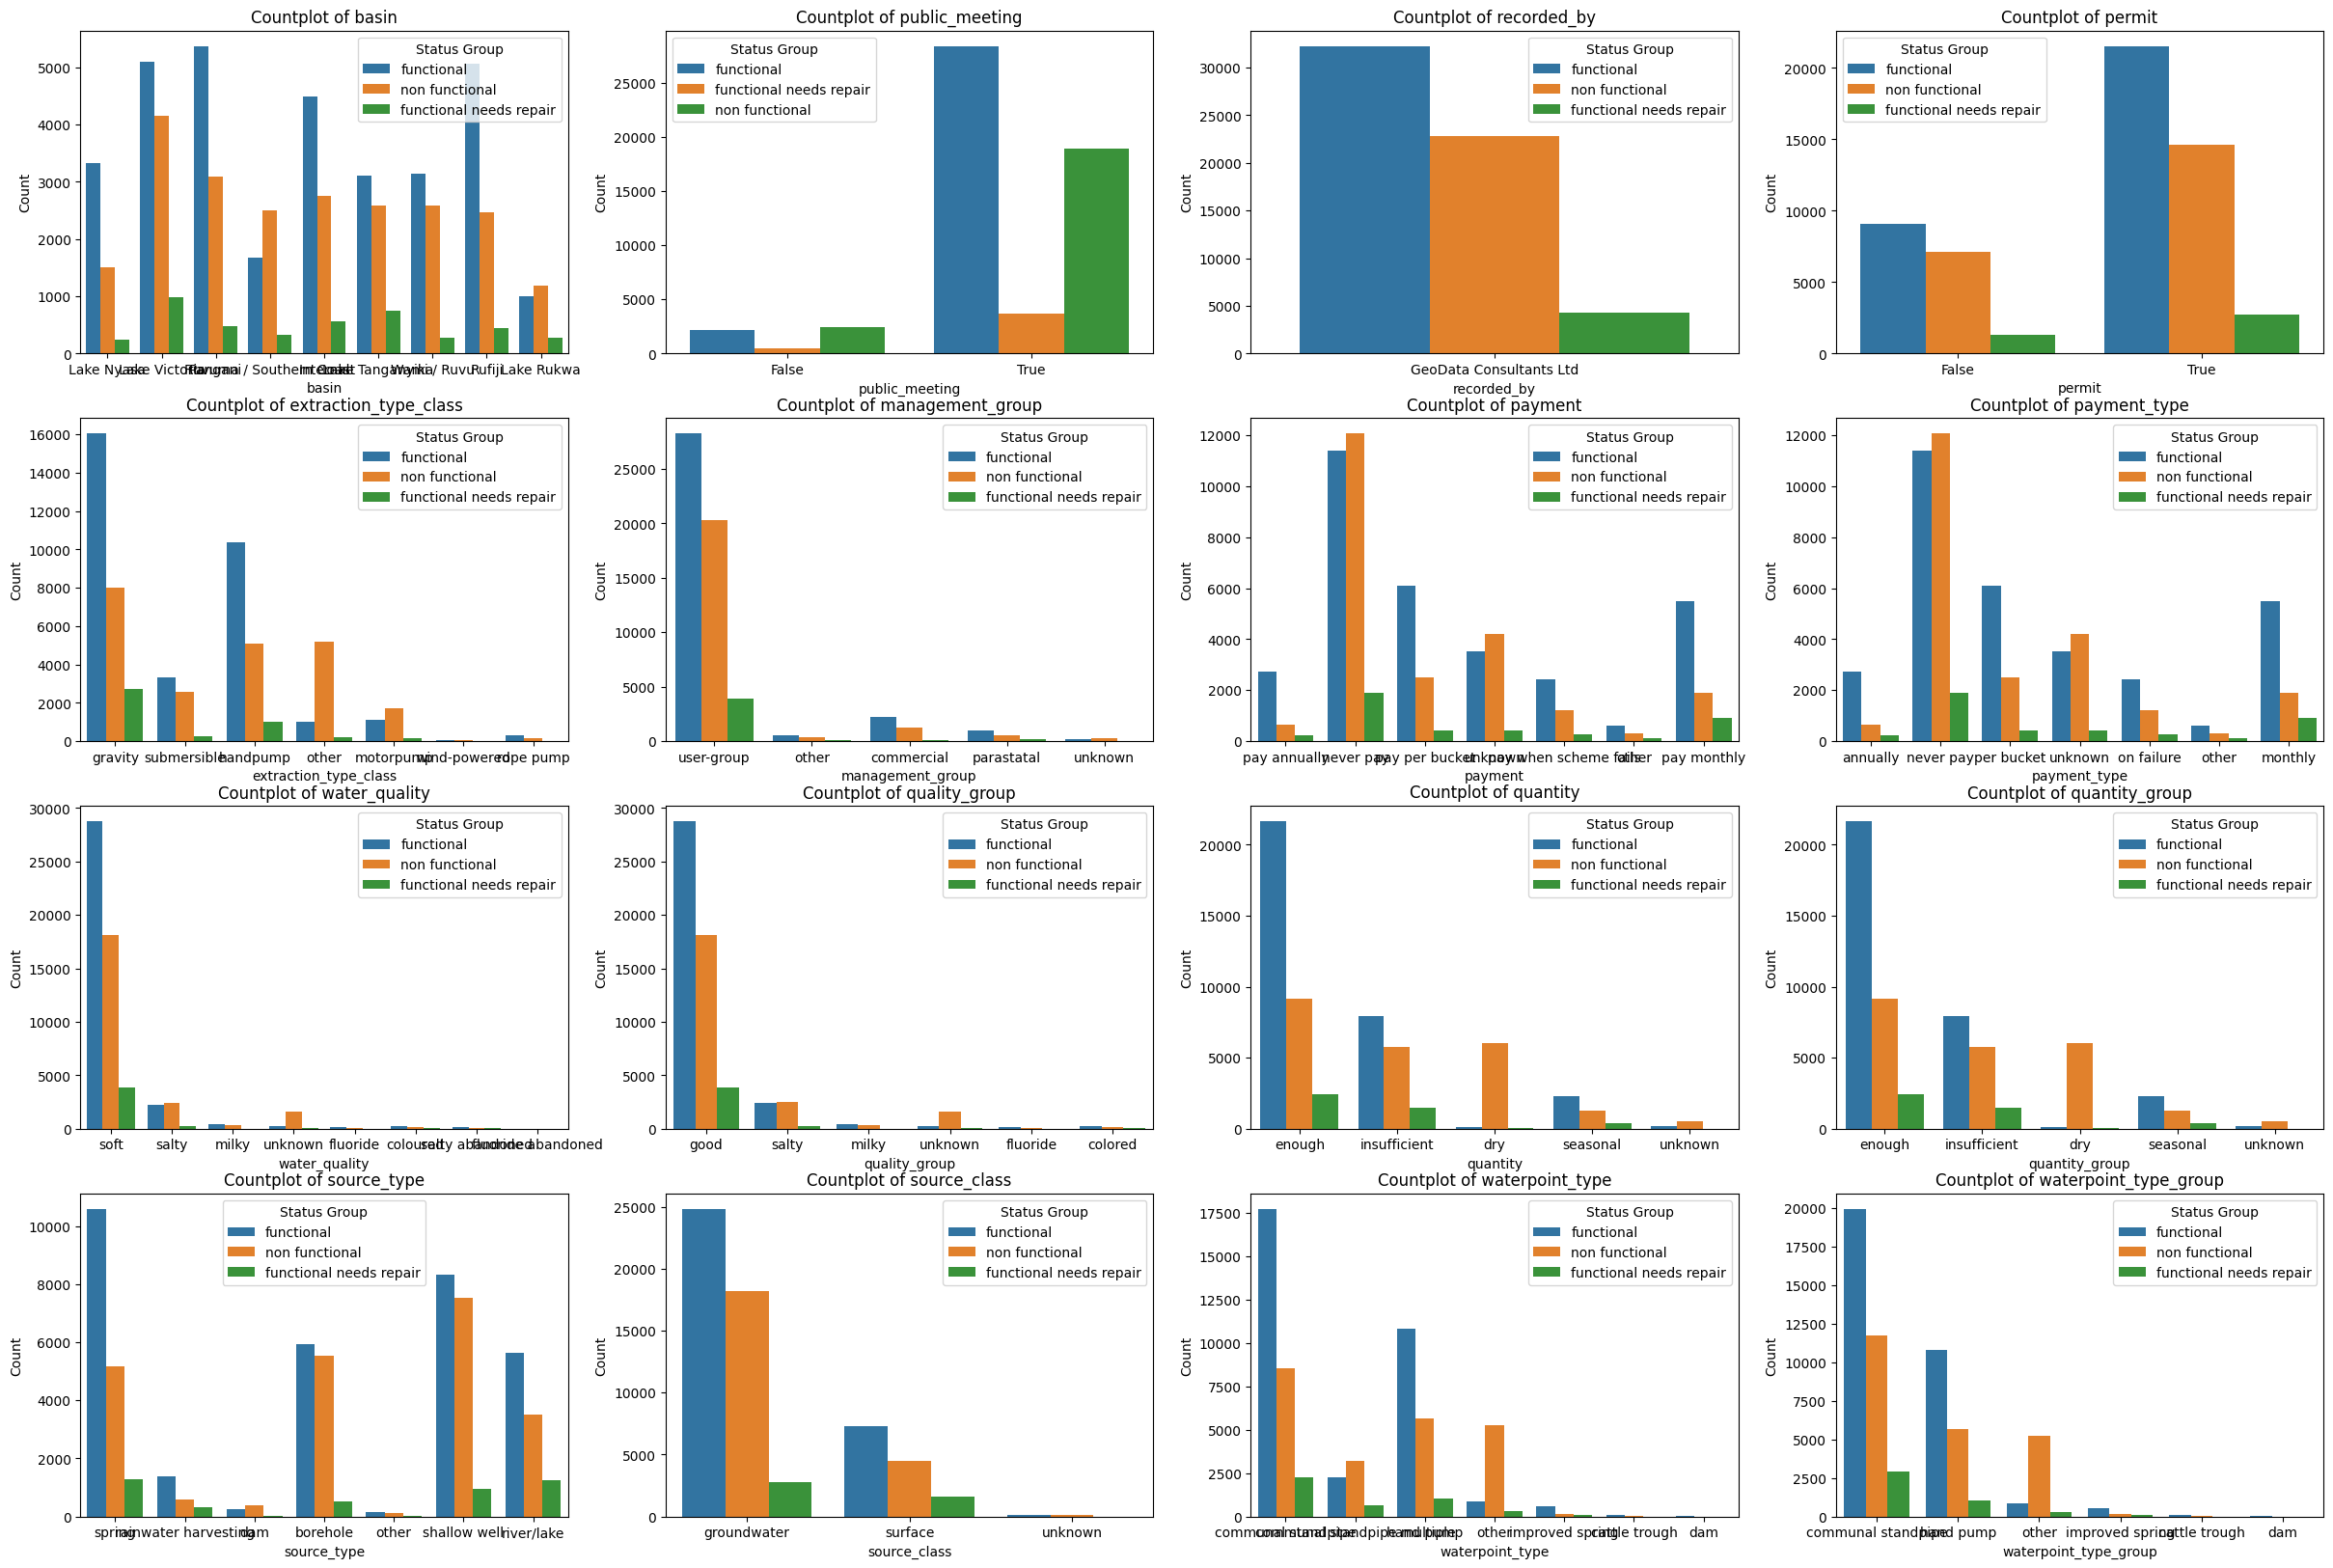

In [54]:
# lets plot them now
plt.figure(figsize=(30, 20))

for i, feature in enumerate(features_to_plot, 1):
    plt.subplot(4, 4, i)
    sns.countplot(x=feature, data=train_df, hue='status_group') # type: ignore
    plt.title(f"Countplot of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.legend(title="Status Group")

# plt.tight_layout()
plt.show()

In [ ]:
# something u can directly see nearly all of them are functional
# which is a problem that is caused due to the imbalance in the target variable
# making it really hard to see any patterns in the data 
# however u can also notice something interesting which is that in the feature "quantity" which indicates the quantity of water that the pump provides,
# being "dry" seems to be a really strong indicator that the pump is non functional
# which makes sense since if the pump is dry it is most likely not working, 
# and this can be a really good feature to predict the target variable
# making it a really good feature to predict the target variable

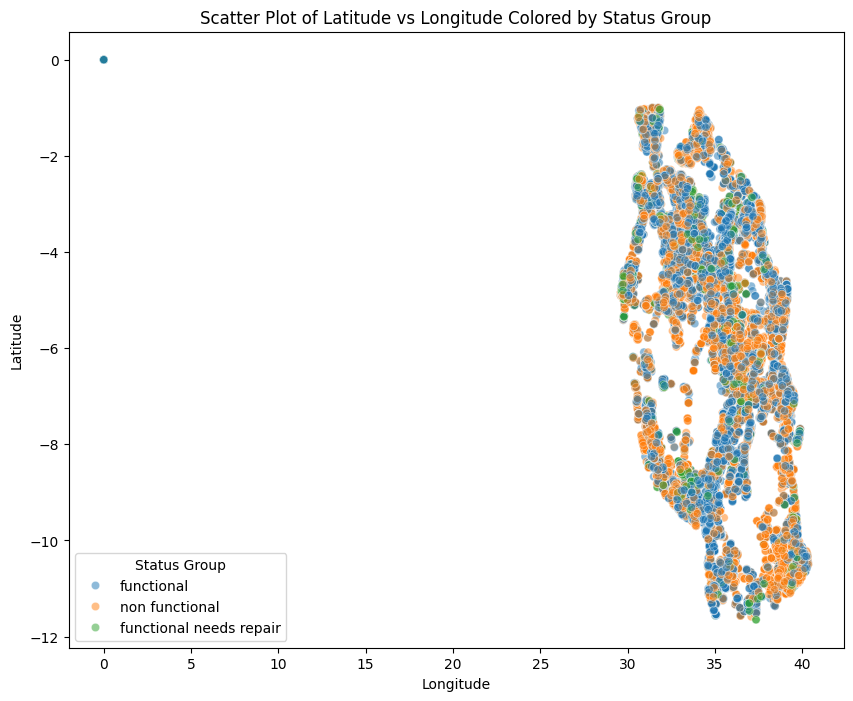

In [61]:
# lets check if latitude and longtitude together can give us any insights about the target variable

plt.figure(figsize=(10, 8))

sns.scatterplot(x='longitude', y='latitude', hue='status_group', data=train_df, alpha=0.5) # type: ignore
plt.title("Scatter Plot of Latitude vs Longitude Colored by Status Group")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Status Group")
plt.show()

In [ ]:
# we can see that there is no clear pattern in the data, t
# he different classes are evenly distributed across the different values of latitude and longitude